# 🩺 Stroke Prediction

## Overview
This notebook contains a deep learning classification exercise completed during the AI Bootcamp. The project aims to predict the likelihood of stroke using patient demographic and health-related information.

## Objective
The goal of this exercise is to build and evaluate a fully connected neural network capable of predicting stroke occurrence from structured healthcare data.

## Dataset
The dataset includes patient characteristics such as age, health conditions, lifestyle factors, and medical history. The target variable indicates whether the patient experienced a stroke.

## Skills Practiced

- Data Preprocessing
- Feature Engineering
- Binary Classification
- Deep Neural Networks
- Model Evaluation
- Keras

---
**Tools:** Python, NumPy, Pandas, TensorFlow, Keras

In [3]:
import pandas as pd 
df = pd.read_csv('stroke-data.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


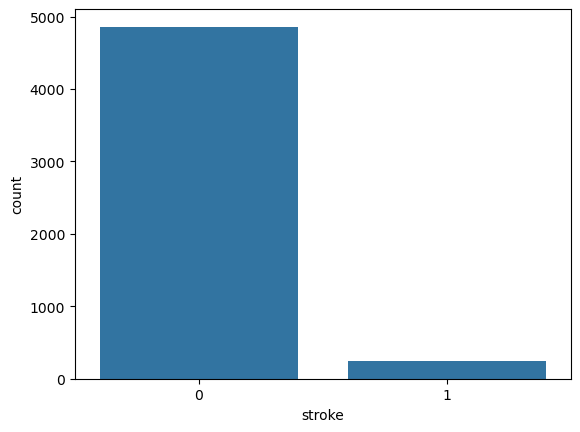

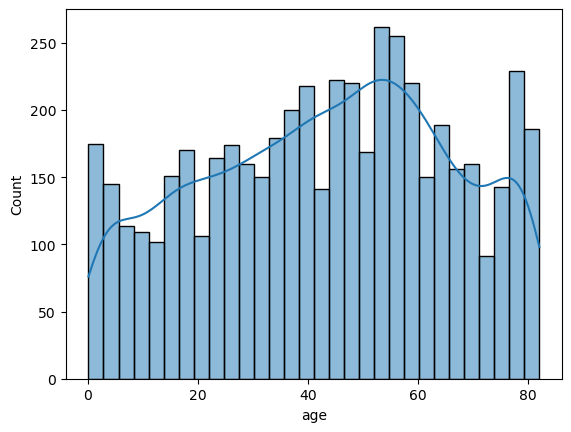

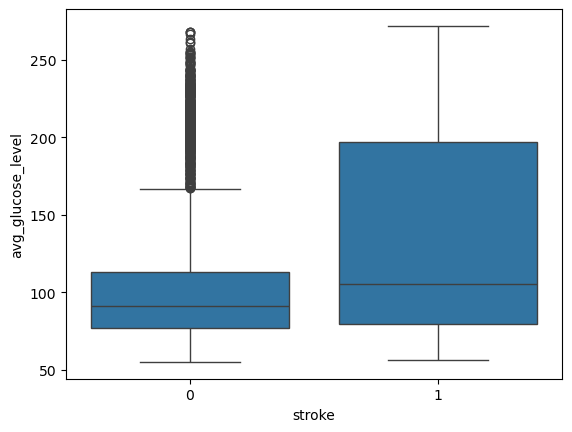

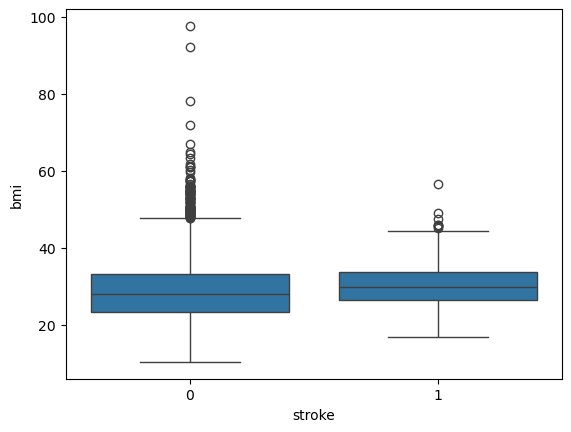

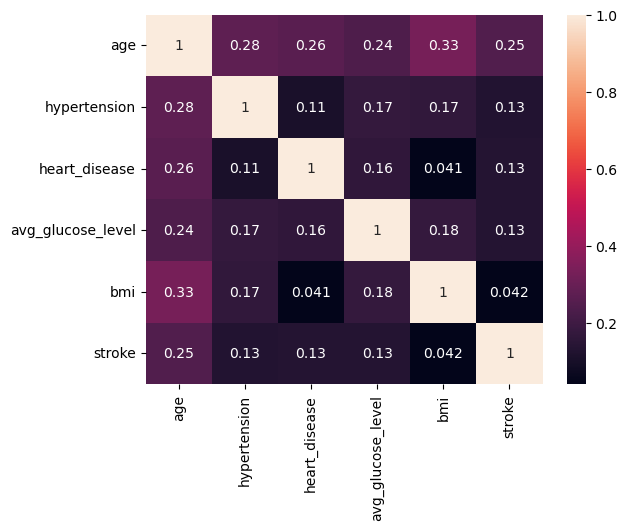

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.head()

df.info()

df.describe()

df['stroke'].value_counts(normalize=True)

plt.figure()
sns.countplot(x='stroke', data=df)
plt.show()

plt.figure()
sns.histplot(df['age'], bins=30, kde=True)
plt.show()

plt.figure()
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.show()

plt.figure()
sns.boxplot(x='stroke', y='bmi', data=df)
plt.show()

plt.figure()
corr = df[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']].corr()
sns.heatmap(corr, annot=True)
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns=['stroke', 'id'])
y = df['stroke']

numeric_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

input_dim = X_train.shape[1]

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=input_dim))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Users\MY-PC\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\MY-PC\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Train Loss:", train_loss)
print("Train Accuracy:", train_acc)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9554 - loss: 0.1337 - val_accuracy: 0.9389 - val_loss: 0.2116
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9541 - loss: 0.1343 - val_accuracy: 0.9389 - val_loss: 0.2190
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9550 - loss: 0.1286 - val_accuracy: 0.9389 - val_loss: 0.2122
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9560 - loss: 0.1247 - val_accuracy: 0.9377 - val_loss: 0.2230
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9566 - loss: 0.1276 - val_accuracy: 0.9401 - val_loss: 0.2311
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9550 - loss: 0.1324 - val_accuracy: 0.9377 - val_loss: 0.2166
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9557 - loss: 0.1303 - val_accuracy: 0.9389 - val_loss: 0.2231
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9544 - loss: 0.1267 - val_accuracy: 0.

In [15]:
loss, accuracy = model.evaluate(X_train, y_train)
print(f"Train Loss: {loss:.4f}, Train Accuracy: {accuracy:.4f}")

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.9569 - loss: 0.1296
Train Loss: 0.1296, Train Accuracy: 0.9569


In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.9472 - loss: 0.2024
Test Loss: 0.2024, Test Accuracy: 0.9472


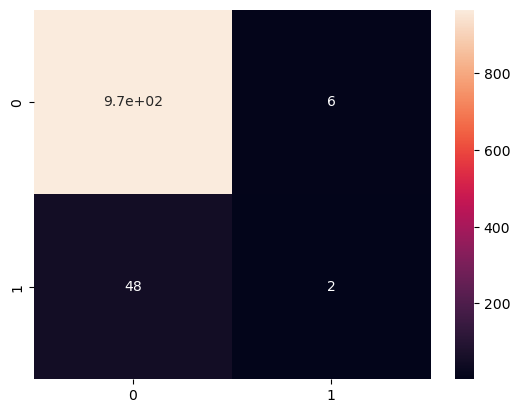

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True)
plt.savefig('confusion.png')

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.25      0.04      0.07        50

    accuracy                           0.95      1022
   macro avg       0.60      0.52      0.52      1022
weighted avg       0.92      0.95      0.93      1022



In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,413 (130.52 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,276 (87.02 KB)

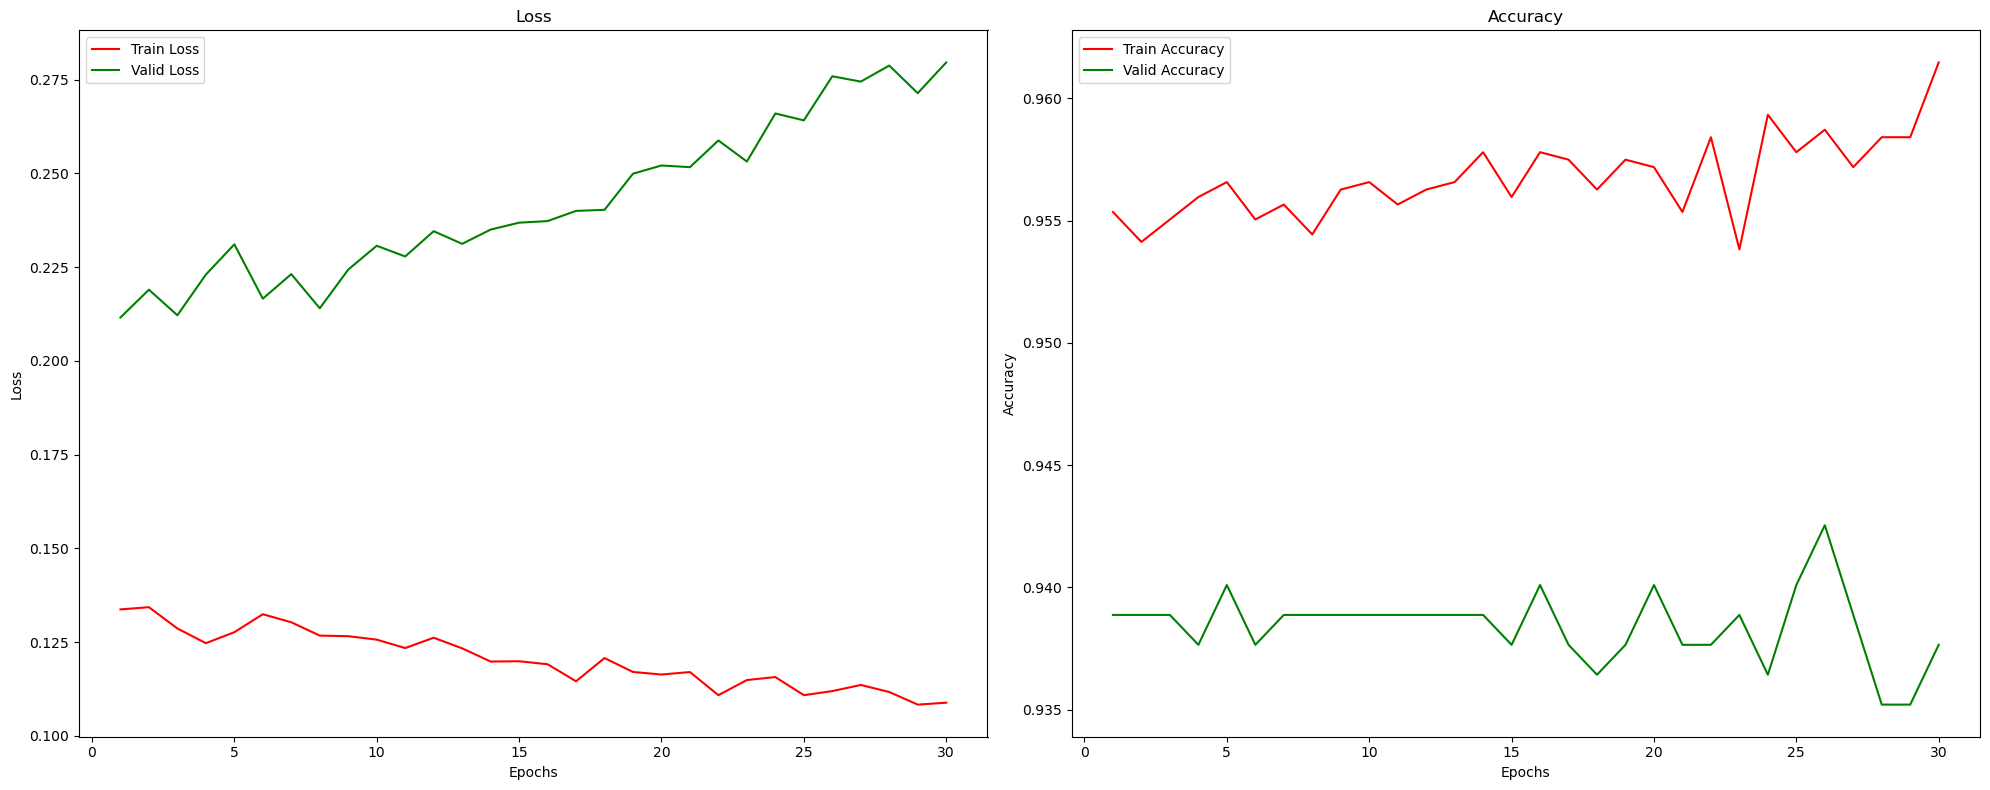

In [22]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = [i+1 for i in range(len(tr_acc))]

plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs, tr_loss, 'r', label='Train Loss')
plt.plot(epochs, val_loss, 'g', label='Valid Loss')
plt.title('Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(epochs, tr_acc, 'r', label='Train Accuracy')
plt.plot(epochs, val_acc, 'g', label='Valid Accuracy')
plt.title('Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()